# XGBoost Baseline
Same dataset, same feature set as `build_model_weather.ipynb` (LightGBM) —
the two gradient-boosted tree models are the closest comparison pair in the
chain, since both support native categorical handling and early stopping.
Differences between the two here come down to the boosting implementation
(histogram-based, but different regularization/growth defaults), not
feature engineering.

**Split strategy note:** same as the other notebooks — random group-split by
`trip_id` for the current single-day dataset. Switch `USE_CHRONOLOGICAL_SPLIT`
to `True` once the dataset spans multiple months, and keep this setting
consistent across all baseline notebooks so results stay comparable.

In [2]:
import numpy as np
import polars as pl
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [3]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"

# Toggle this once the dataset spans multiple months (see note above).
# Requires a `service_date` column in df.
USE_CHRONOLOGICAL_SPLIT = False
CHRONOLOGICAL_SPLIT_DATE = "2026-06-01"  # train < this date, test >= this date

df = pl.read_parquet(DATA_PATH)
print(df.shape)

TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id", 'is_raining', 'is_snowing', 'is_fog', "is_weekend",
    "is_federal_holiday",
    "is_school_day",
    "has_major_event",]
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
    'temperature_c', 'precipitation_mm', 'snowfall_cm', 'windspeed_kmh', 'weathercode',
    'segment_length',
    'scheduled_segment_speed_mps',
    'upstream_delay_seconds',
    'speed_mps',
    'headway_seconds',
    "ridership",
    "transfers",
]

FEATURES = CATEGORICAL + NUMERIC

(5596768, 40)


## Split
Identical split logic to `build_model_lr.ipynb` / `build_model_weather.ipynb`
so all baselines are evaluated on the exact same train/test rows.

In [4]:
if USE_CHRONOLOGICAL_SPLIT:
    assert "service_date" in df.columns, "service_date column required for chronological split"

    train_df = df.filter(pl.col("service_date") < CHRONOLOGICAL_SPLIT_DATE)
    test_df = df.filter(pl.col("service_date") >= CHRONOLOGICAL_SPLIT_DATE)

    print(f"[chronological split @ {CHRONOLOGICAL_SPLIT_DATE}]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")
else:
    groups = df["trip_id"].to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df, groups=groups))

    train_df = df[train_idx]
    test_df = df[test_idx]

    print("[random group split by trip_id]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

[random group split by trip_id]
train: (4466158, 40) | test: (1130610, 40)
train trips: 10,387 | test trips: 2,597 | overlap: 0


## Convert to pandas
Same helper used in the LightGBM and LR notebooks. XGBoost, like LightGBM,
can consume pandas `category` dtype columns natively (`enable_categorical=True`
below) — no one-hot encoding needed.

In [5]:
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:
    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series([str(v) for v in s.to_list()], dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)

X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

## Train
`tree_method="hist"` + `enable_categorical=True` is XGBoost's equivalent to
LightGBM's native categorical split handling. Objective/metric
(`reg:absoluteerror` / MAE) and early-stopping setup mirror the LightGBM
notebook so the two are a fair comparison — same loss being optimized, same
patience (50 rounds), same eval set.

In [6]:
model = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    eval_metric="mae",
    n_estimators=10000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=30,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=50,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

XGBoostError: [01:23:42] D:\bld\xgboost-split_1784612048744\work\src\data\../data/cat_container.h:29: Found a category not in the training set for the 3th (0-based) column: `OH_C6-Sunday-BM`

## Evaluate
Same metrics (MAE, RMSE, R²) and the same naive baseline comparison
(predicting `scheduled_segment_time` as-is) used in the LightGBM notebook,
so the two are directly comparable.

In [ ]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
mape = mean_absolute_percentage_error(y_test, preds)
wape = np.abs(y_test - preds).sum() / np.abs(y_test).sum()

print(f"MAPE: {mape*100:.1f}%  (caution: unstable if travel_time has near-zero rows)")
print(f"WAPE: {wape*100:.1f}%")
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")
naive_wape = np.abs(y_test - naive_preds).sum() / np.abs(y_test).sum()
print(f"Naive baseline WAPE: {naive_wape*100:.1f}%")

MAE:  30.9 sec
RMSE: 59.2 sec
R2:   0.4598
MAPE: 63.4%  (caution: unstable if travel_time has near-zero rows)
WAPE: 31.3%

Naive baseline (scheduled_segment_time only) MAE: 47.4 sec
Improvement over naive: 34.8%
Naive baseline WAPE: 48.0%


## Feature importances
Same idea as `feature_importances_` in the LightGBM notebook — here XGBoost's
default "gain"-based importance per feature.

shape: (37, 2)
┌────────────────────────┬────────────┐
│ feature                ┆ importance │
│ ---                    ┆ ---        │
│ str                    ┆ f32        │
╞════════════════════════╪════════════╡
│ segment_length         ┆ 0.087644   │
│ transfers              ┆ 0.072411   │
│ hour                   ┆ 0.061381   │
│ scheduled_segment_time ┆ 0.041042   │
│ stop_lat               ┆ 0.040539   │
│ …                      ┆ …          │
│ is_weekend             ┆ 0.0        │
│ is_federal_holiday     ┆ 0.0        │
│ is_school_day          ┆ 0.0        │
│ has_major_event        ┆ 0.0        │
│ snowfall_cm            ┆ 0.0        │
└────────────────────────┴────────────┘


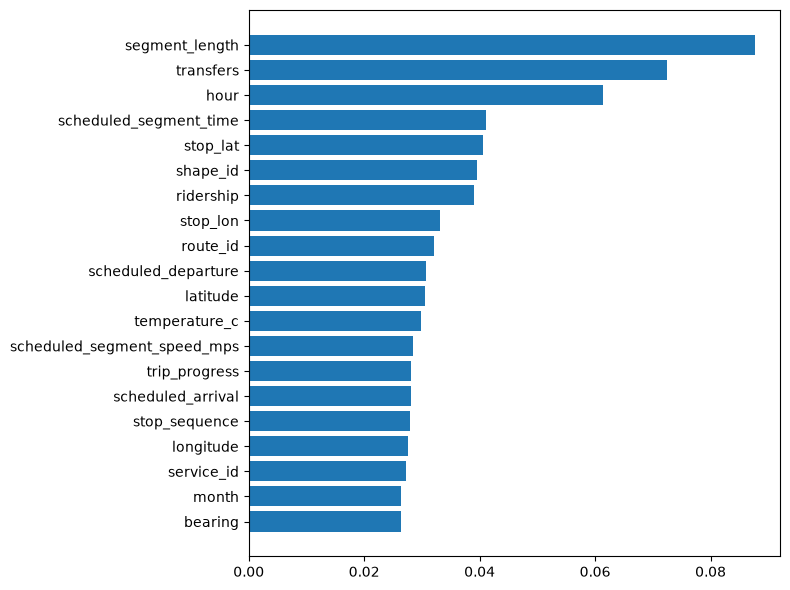

In [ ]:
importance = (
    pl.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": model.feature_importances_,
    })
    .sort("importance", descending=True)
)
print(importance)

import matplotlib.pyplot as plt

top = importance.head(20).to_pandas()
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Save
Saved via XGBoost's native `save_model` as `.json` (XGBoost's recommended
format — portable across versions, unlike pickling the sklearn wrapper).
Naming mirrors the LightGBM `.txt` booster dump so the two are easy to pair
up in `models/`.

In [ ]:
# model.save_model("models/xgb_weather_segments_delay_and_ridership.json")
# print("model saved")

model saved
